In [1]:
import sys
sys.path.append('..')

from ontology_handling import TreeHelper
from dharani_functions import DharaniHelper
from annotation_handling import get_properties


In [2]:
helper = DharaniHelper(specimennum=3, downsample=0)

In [3]:
print(helper)

Dharani_Specimen_3, downsample=0


In [4]:
len(helper.get_section_numbers())

540

In [5]:
helper.get_filenames?

Signature: helper.get_filenames()
Docstring:
List the files in s3 bucket corresponding to this specimen;
Returns a dict: secno->{'image':image_tif_filename, 'annotation':annotation_json_filename}
the key 'annotation' exists only for annotated sections.
File:      c:\users\keerthi\code\hbp\sgbc_dharani_data_tutorial\dharani_data_tutorial\dharani_functions.py
Type:      method

In [6]:
secnames = helper.get_filenames()

In [7]:
secnames[1000]

{'image': 'Specimen_3_1000.tif', 'annotation': 'Specimen_3_1000.json'}

In [8]:
len(secnames)

540

Filter annotated sections

In [9]:
sections = [sec for sec in secnames if 'annotation' in secnames[sec]]

In [10]:
len(sections)

69

## Get the annotation data
get_annotation creates shapely geometries, which can be used to get properties

In [11]:
helper.get_annotation(1)

{}

In [14]:
%%time
annotations_by_ontoid = helper.get_annotations(concurrent=True)

CPU times: total: 219 ms
Wall time: 23.4 s


## organize the annotations to get counts, areas etc

In [15]:
from collections import defaultdict

In [16]:
from matplotlib import pyplot as plt
import numpy as np

In [17]:
# sections = set()
cntlist  = defaultdict(dict)

for oid in annotations_by_ontoid:
    seclist = sorted(list(annotations_by_ontoid[oid].keys()))
    # sections=sections.union(set(seclist))
    for sec in seclist:
        geom = annotations_by_ontoid[oid][sec]
        if geom.geom_type=='MultiPolygon':
            cnt = len(geom.geoms)
        else:
            cnt = 1
        cntlist[sec][oid]=cnt

Text(0.5, 1.0, 'number of annotated polygons, against section number')

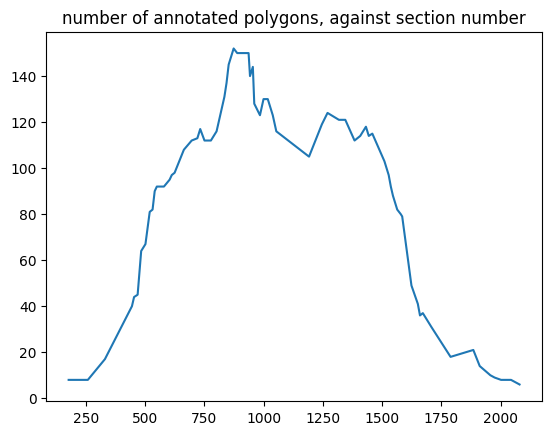

In [18]:
X = sorted(cntlist.keys())
Y = [len(cntlist[x]) for x in X]
plt.plot(X,Y)
plt.title('number of annotated polygons, against section number')

Text(0.5, 1.0, 'gap to next annotated section, against section number')

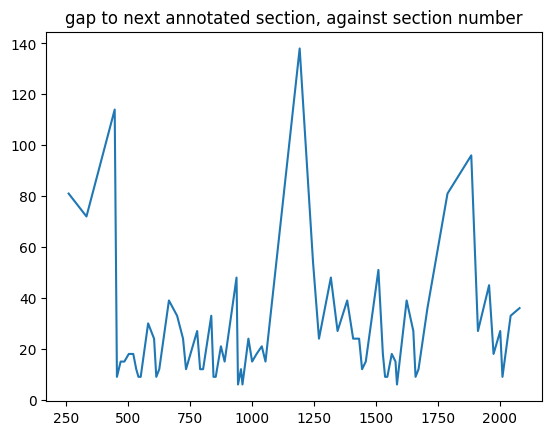

In [19]:
plt.plot(X[1:],np.diff(X))
plt.title('gap to next annotated section, against section number')

In [20]:
np.mean(np.diff(X)), np.median(np.diff(X))

(27.970588235294116, 18.0)

In [21]:
len(sections)

69

View the annotated ontoids by section number

In [33]:
sections[5],cntlist[sections[5]].keys()

(1246,
 dict_keys([329, 165, 247, 253, 284, 176, 245, 229, 1000, 174, 383, 330, 177, 184, 208, 243, 377, 195, 155, 157, 153, 154, 300, 27, 28, 238, 226, 158, 144, 152, 127, 33, 31, 32, 124, 14, 15, 16, 13, 26, 24, 25, 39, 161, 169, 334, 121, 122, 123, 162, 126, 405, 332, 171, 258, 203, 194, 40, 30, 42, 41, 219, 22, 23, 149, 223, 250, 89, 90, 294, 57, 242, 60, 87, 61, 88, 58, 59, 86, 374, 222, 197, 320, 417, 146, 306, 236, 188, 424, 423, 387, 422, 138, 388, 251, 178, 67, 68, 425, 421, 420, 386, 104, 96, 103, 102, 95, 94, 286, 287, 62, 105, 97, 43, 416, 82, 293, 290, 5]))

In [35]:
# type(annot_err[42])

### Load Dharani ontology

In [36]:
dharani_onto_helper = TreeHelper('dharani')

Print all annotated structure names in this specimen (show the full name, and list of sections for each structure) 

In [37]:
for oid in annotations_by_ontoid:
    seclist = sorted(list(annotations_by_ontoid[oid].keys()))
    if len(seclist)>0:
        print(oid, dharani_onto_helper.get_full_name_by_ontoid(oid),seclist)

329 ('Brain/Forebrain/Diencephalon/Thalamus/Ventral complex of the thalamus', 'Br/FB/Di/TH/VEN', 'Ventral anterior nucleus of the thalamus', 'VA') [853, 874, 889, 937, 943, 955, 961, 985, 1000, 1018, 1039, 1054, 1192, 1246, 1270, 1318]
165 ('Brain/Forebrain/Diencephalon/Thalamus/Anterior complex of the thalamus', 'Br/FB/Di/TH/ANT', 'Anteroventral nucleus of the thalamus', 'AV') [961, 985, 1000, 1018, 1039, 1054, 1246, 1270]
247 ('Fiber tracts/Medial forebrain bundle', 'ft/mfb', 'Fornix', 'fx') [445, 454, 469, 484, 502, 520, 532, 541, 550, 580, 604, 613, 625, 664, 697, 721, 733, 751, 778, 790, 802, 835, 844, 853, 874, 889, 937, 943, 955, 961, 985, 1000, 1018, 1039, 1054, 1192, 1246, 1270, 1318, 1345, 1384, 1408, 1432, 1444, 1459, 1510, 1528, 1537, 1546, 1564, 1579, 1585, 1624]
253 ('Fiber tracts', 'ft', 'White matter fibers', 'wmf') [454, 469, 484, 502, 532, 541, 550, 580, 604, 613, 625, 664, 697, 721, 733, 751, 778, 790, 802, 835, 844, 853, 874, 889, 937, 943, 955, 961, 985, 1000, 1018

Find the `ontoid` of Thalamus and temporal cortex, using `dharani_onto_helper`

In [38]:
search_str =  'Thalamus' # 'temporal' #
dharani_onto_helper.search(search_str, partial=True)

[SearchResult(matched_name='thalamus', score=100.0, ontoid=160),
 SearchResult(matched_name='dorsal complex of the thalamus', score=100.0, ontoid=254),
 SearchResult(matched_name='medial dorsal nucleus of the thalamus', score=100.0, ontoid=161),
 SearchResult(matched_name='nucleus fasciculosus of the thalamus', score=100.0, ontoid=459),
 SearchResult(matched_name='lateral dorsal nucleus of the thalamus', score=100.0, ontoid=162)]

Find successors of Thalamus (or Temporal Cortex), defined in the ontology

In [39]:
resid= 160 # 47 #
search_successors=dharani_onto_helper.get_successor_ids(resid)

In [40]:
for ch_id in search_successors:
    print(ch_id, dharani_onto_helper.get_full_name_by_ontoid(ch_id))

254 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Dorsal complex of the thalamus', 'DOR')
260 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Periventricular complex of the thalamus', 'PVTH')
256 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Anterior complex of the thalamus', 'ANT')
257 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Central complex of the thalamus', 'CTH')
259 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Posterior complex of the thalamus', 'POT')
282 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Ventral complex of the thalamus', 'VEN')
172 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Habenula', 'H')
173 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Epithalamus', 'EPI')
176 ('Brain/Forebrain/Diencephalon/Thalamus', 'Br/FB/Di/TH', 'Reticular nucleus of the thalamus', 'RT')
161 ('Brain/Forebrain/Diencephalon/Thalamus/Dorsal complex of the thalamus', 'Br/FB/Di/TH/DOR', 'Medial do

Find these in the annotations; map from secno to dict of ontoid:geometry

In [41]:
len(search_successors)

46

In [42]:
search_annotations = defaultdict(dict)

for ch in [resid]+search_successors:
    if ch in annotations_by_ontoid:
        for secno in annotations_by_ontoid[ch]:
            search_annotations[secno][ch]=annotations_by_ontoid[ch][secno]
        

the 2d equivalent of the above block is in nb_functions.py `display_annotation` with ontoids passed. Here we are doing it for the whole brain

In [43]:
X = [] # section numbers
Y = [] # number of thalamic annotations

for secno in sorted(search_annotations):
    X.append(secno)
    print(secno, search_annotations[secno].keys())
    Y.append(len(search_annotations[secno].keys()))

580 dict_keys([176, 167])
604 dict_keys([176, 167, 169])
613 dict_keys([176, 167, 169])
625 dict_keys([176, 167, 432, 169])
664 dict_keys([176, 167, 419, 432, 169, 331])
697 dict_keys([176, 167, 419, 432, 169, 331])
721 dict_keys([176, 167, 432, 169, 331])
733 dict_keys([176, 416, 167, 168, 400, 432, 169, 331])
751 dict_keys([176, 416, 168, 400, 169, 331])
778 dict_keys([176, 416, 168, 400, 169, 331, 332])
790 dict_keys([176, 416, 168, 400, 169, 330, 331, 332])
802 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174])
835 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174])
844 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174])
853 dict_keys([176, 162, 416, 168, 169, 329, 330, 383, 331, 332, 174])
874 dict_keys([176, 162, 416, 258, 405, 169, 329, 330, 383, 331, 332, 402, 174])
889 dict_keys([176, 162, 416, 258, 405, 169, 329, 330, 383, 331, 332, 402, 174])
937 dict_keys([176, 161, 162, 416, 171, 258, 405, 169, 329, 330, 383, 332, 402, 174])
943 dict_keys([176, 161, 162, 41

Text(0.5, 1.0, 'number of `Thalamus` annotations, against section number')

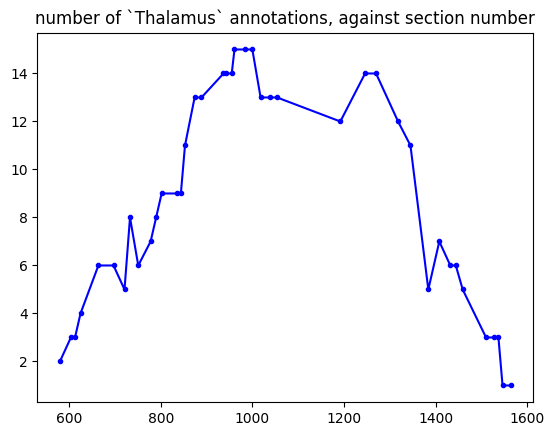

In [44]:
plt.plot(X,Y,'b.-')
plt.title(f'number of `{search_str}` annotations, against section number')

In [69]:
secno = X[0] # 985 # 589

for ontoid in search_annotations[secno]:
    shp = search_annotations[secno][ontoid]
    
    print(ontoid, dharani_onto_helper.onto_lookup[ontoid])
    props = get_properties(shp)
    print(props)

176 NodeRecord(acronym='RT', name='Reticular nucleus of the thalamus', color_hex_triplet='#B067A9', level=4, parentid=160, numchildren=0)
{'pt': (37277.25848376224, 35281.36571004222), 'area': 9738690.274404371, 'perimeter': 16710.187820119016, 'numcomp': 1, 'bbox': (35875.26843275712, 31955.775745022176, 39577.39789522173, 38649.412759574465), 'aspectratio': 2.4577725397805605, 'obb': <POLYGON ((36796.157 39362.477, 35043.608 32526.82, 37824.849 31813.756, 395...>, 'majoraxislength': 7056.743973451609, 'minoraxislength': 2871.1948966935984, 'maxwidth': 2187.7177803810755, 'orientation': 75.6200478682251}
167 NodeRecord(acronym='LGN', name='Lateral geniculate nucleus', color_hex_triplet='#F7D0BB', level=5, parentid=259, numchildren=0)
{'pt': (35151.190860394345, 37403.90637539378), 'area': 3338962.5598943564, 'perimeter': 8502.567217679441, 'numcomp': 1, 'bbox': (34312.24676459612, 35768.621375622475, 36221.92886871553, 39008.664530876194), 'aspectratio': 1.890225145592626, 'obb': <POL

Get areas

In [72]:

X = [] # section numbers
Y = [] # area of thalamic annotations

for secno in sorted(search_annotations):
    X.append(secno)
    print(secno,search_annotations[secno].keys(), end=' ')
    ar_sec = 0
    for ontoid in search_annotations[secno]:
        shp = search_annotations[secno][ontoid]
        props = get_properties(shp)
        ar_sec+=props['area']
    print(ar_sec)
    Y.append(ar_sec)

580 dict_keys([176, 167]) 13077652.834298728
604 dict_keys([176, 167, 169]) 18620826.200512245
613 dict_keys([176, 167, 169]) 20402145.006604813
625 dict_keys([176, 167, 432, 169]) 28294253.098540653
664 dict_keys([176, 167, 419, 432, 169, 331]) 37673146.07585799
697 dict_keys([176, 167, 419, 432, 169, 331]) 41517478.06330122
721 dict_keys([176, 167, 432, 169, 331]) 46779745.50227067
733 dict_keys([176, 416, 167, 168, 400, 432, 169, 331]) 52159913.5275604
751 dict_keys([176, 416, 168, 400, 169, 331]) 58262239.27398029
778 dict_keys([176, 416, 168, 400, 169, 331, 332]) 67441604.81206225
790 dict_keys([176, 416, 168, 400, 169, 330, 331, 332]) 73074960.07903783
802 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174]) 73560220.0724884
835 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174]) 71670531.33255352
844 dict_keys([176, 416, 168, 169, 330, 383, 331, 332, 174]) 70169967.79040706
853 dict_keys([176, 162, 416, 168, 169, 329, 330, 383, 331, 332, 174]) 76334684.65277694
874 dict

Text(0.5, 1.0, 'area of `Thalamus` annotated, against section number')

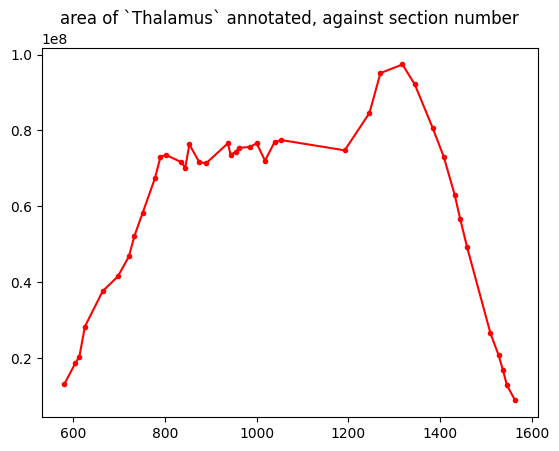

In [48]:
plt.plot(X,Y,'r.-')
plt.title(f'area of `{search_str}` annotated, against section number')

In [50]:
mid=(max(sections)+min(sections))//2

In [51]:
mid

1129

In [52]:
split_pos = np.where(np.array(X)<mid)[0].max()+1

In [53]:
split_pos

26

In [54]:
len(X)

41

In [55]:
X[split_pos-1]

1054

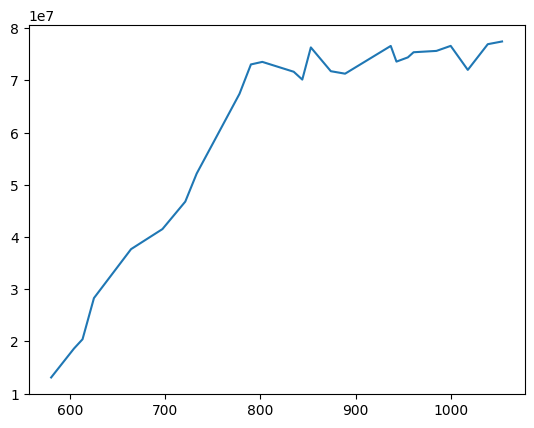

In [56]:
plt.plot(X[:split_pos],Y[:split_pos])

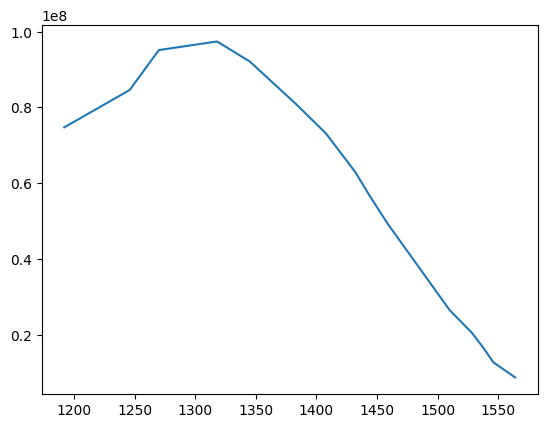

In [57]:
plt.plot(X[split_pos:],Y[split_pos:])

In [58]:
v_left=np.trapz(Y[:split_pos],X[:split_pos])

In [59]:
v_right=np.trapz(Y[split_pos:],X[split_pos:])

In [60]:
v_left/v_right

1.1337715173248781

in mm^3; @1mpp, 1pix = 1umsq = 10^-6mmsq; section thickness is 20um = 0.02mm; vol of 1 pix is 0.02*10^-6 mm3 

In [63]:
v_left*(10**-6)*0.02 , v_right*(10**-6)*0.02

(563.6815137267448, 497.1738177518742)